# Assignment 1: Data Exploration and Analysis
## FreshRetailNet-50K Dataset

**Objective:** Comprehensive exploratory data analysis of the retail demand forecasting dataset to understand data characteristics, distributions, patterns, and business insights.

### Contents:
1. Data Loading and Overview
2. Data Quality Assessment
3. Statistical Analysis
4. Temporal Patterns and Seasonality
5. Business Dimensions Analysis
6. Feature Correlations
7. Key Insights and Recommendations

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import yaml
import warnings
import sys

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Add src to path
sys.path.append('src')

from data.data_loader import FreshRetailDataLoader
from data.feature_engineering import FeatureEngineer

# Load configuration
with open('config/config.yaml', 'r') as f:
    config = yaml.safe_load(f)

# Load data
loader = FreshRetailDataLoader()
train_data, eval_data = loader.load_data()

print("✓ Data loaded successfully")
print(f"  Training set: {train_data.shape}")
print(f"  Evaluation set: {eval_data.shape}")

✓ Data loaded successfully
  Training set: (450000, 19)
  Evaluation set: (35000, 19)


## 2. Data Overview and Schema

In [2]:
# Display basic information
print("=" * 80)
print("DATASET SCHEMA AND BASIC STATISTICS")
print("=" * 80)

print("\n📊 Data Types:")
print(train_data.dtypes)

print("\n📋 First Few Rows:")
print(train_data.head())

print("\n📈 Shape and Size:")
print(f"Training data: {train_data.shape[0]:,} rows × {train_data.shape[1]} columns")
print(f"Evaluation data: {eval_data.shape[0]:,} rows × {eval_data.shape[1]} columns")

print("\n🔢 Memory Usage:")
print(f"Training data: {train_data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Evaluation data: {eval_data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

DATASET SCHEMA AND BASIC STATISTICS

📊 Data Types:
city_id                         int64
store_id                        int64
management_group_id             int64
first_category_id               int64
second_category_id              int64
third_category_id               int64
product_id                      int64
dt                     datetime64[us]
sale_amount                   float64
hours_sale                     object
stock_hour6_22_cnt              int32
hours_stock_status             object
discount                      float64
holiday_flag                    int32
activity_flag                   int32
precpt                        float64
avg_temperature               float64
avg_humidity                  float64
avg_wind_level                float64
dtype: object

📋 First Few Rows:
         city_id  store_id  management_group_id  first_category_id  \
2688763        4       832                    2                 29   
491106         0       154                    6       

## 3. Target Variable Analysis

TARGET VARIABLE: sale_amount

📊 Descriptive Statistics:
count    450000.000000
mean          0.994182
std           1.384504
min           0.000000
25%           0.400000
50%           0.700000
75%           1.100000
max          40.400000
Name: sale_amount, dtype: float64


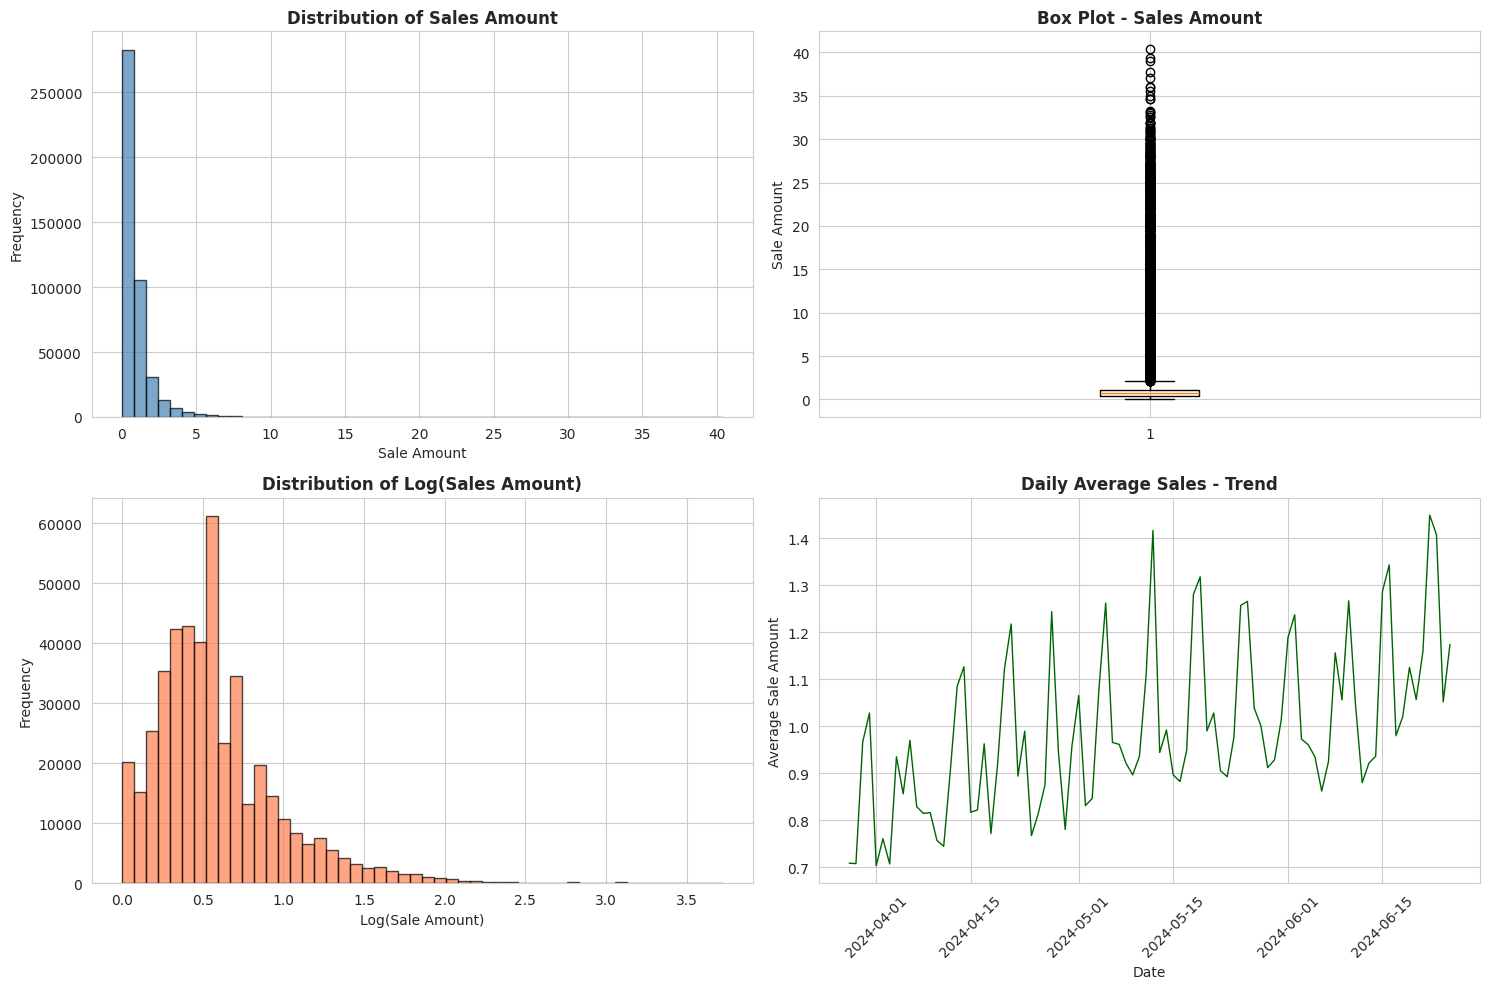


📈 Key Insights:
  • Mean: 0.9942
  • Median: 0.7000
  • Std Dev: 1.3845
  • Skewness: 8.3824
  • Kurtosis: 121.5594
  • Min: 0.0000
  • Max: 40.4000


In [3]:
target_col = config['data']['target_column']

print("=" * 80)
print(f"TARGET VARIABLE: {target_col}")
print("=" * 80)

print("\n📊 Descriptive Statistics:")
print(train_data[target_col].describe())

# Create target analysis plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram
axes[0, 0].hist(train_data[target_col], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Sales Amount', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Sale Amount')
axes[0, 0].set_ylabel('Frequency')

# Box plot
axes[0, 1].boxplot(train_data[target_col])
axes[0, 1].set_title('Box Plot - Sales Amount', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Sale Amount')

# Log-scale histogram (if there are large outliers)
axes[1, 0].hist(np.log1p(train_data[target_col]), bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Distribution of Log(Sales Amount)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Log(Sale Amount)')
axes[1, 0].set_ylabel('Frequency')

# Time series of mean sales
daily_sales = train_data.set_index('dt')[target_col].resample('D').mean()
axes[1, 1].plot(daily_sales, linewidth=1, color='darkgreen')
axes[1, 1].set_title('Daily Average Sales - Trend', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Average Sale Amount')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n📈 Key Insights:")
print(f"  • Mean: {train_data[target_col].mean():.4f}")
print(f"  • Median: {train_data[target_col].median():.4f}")
print(f"  • Std Dev: {train_data[target_col].std():.4f}")
print(f"  • Skewness: {train_data[target_col].skew():.4f}")
print(f"  • Kurtosis: {train_data[target_col].kurtosis():.4f}")
print(f"  • Min: {train_data[target_col].min():.4f}")
print(f"  • Max: {train_data[target_col].max():.4f}")

## 4. Missing Values Analysis

In [4]:
print("=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)

# Calculate missing values
missing_train = train_data.isnull().sum()
missing_eval = eval_data.isnull().sum()

missing_df = pd.DataFrame({
    'Train_Count': missing_train,
    'Train_Percent': (missing_train / len(train_data) * 100).round(2),
    'Eval_Count': missing_eval,
    'Eval_Percent': (missing_eval / len(eval_data) * 100).round(2)
})

missing_df = missing_df[missing_df.sum(axis=1) > 0].sort_values('Train_Percent', ascending=False)

if len(missing_df) == 0:
    print("\n✓ No missing values found in the dataset!")
else:
    print("\n🔴 Missing Values by Column:")
    print(missing_df)

# Visualize missing values
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    missing_df['Train_Percent'].sort_values(ascending=True).plot(kind='barh', ax=ax, color='coral')
    ax.set_title('Missing Values Percentage (Training Data)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Percentage Missing (%)')
    plt.tight_layout()
    plt.show()

MISSING VALUES ANALYSIS

✓ No missing values found in the dataset!


## 5. Temporal Analysis and Seasonality

TEMPORAL PATTERNS AND SEASONALITY

⏰ Time Range:
  • Start: 2024-03-28 00:00:00
  • End: 2024-06-25 00:00:00
  • Duration: 89 days


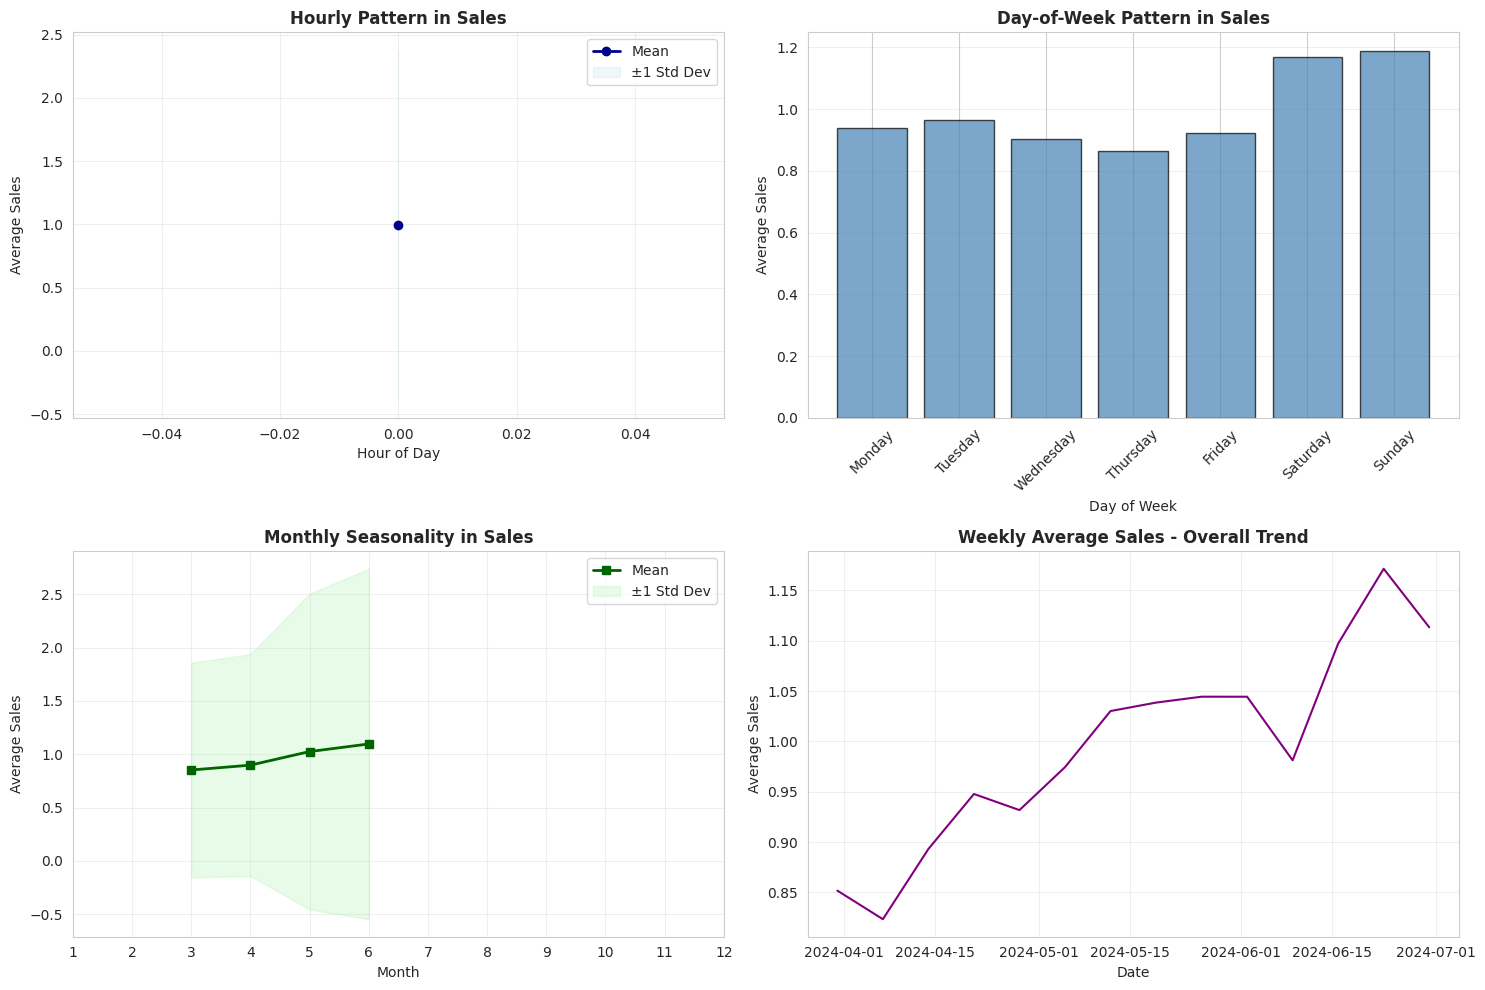


📊 Temporal Statistics:
  • Hourly variation (Std of hourly means): nan
  • Day-of-week variation (Std of daily means): 0.1309
  • Monthly variation (Std of monthly means): 0.1127


In [5]:
print("=" * 80)
print("TEMPORAL PATTERNS AND SEASONALITY")
print("=" * 80)

# Convert datetime
train_data['dt'] = pd.to_datetime(train_data['dt'])

# Extract temporal features
train_data['hour'] = train_data['dt'].dt.hour
train_data['day_of_week'] = train_data['dt'].dt.dayofweek
train_data['month'] = train_data['dt'].dt.month
train_data['day_of_month'] = train_data['dt'].dt.day

print("\n⏰ Time Range:")
print(f"  • Start: {train_data['dt'].min()}")
print(f"  • End: {train_data['dt'].max()}")
print(f"  • Duration: {(train_data['dt'].max() - train_data['dt'].min()).days} days")

# Hourly patterns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Hourly averages
hourly_avg = train_data.groupby('hour')[target_col].agg(['mean', 'std'])
axes[0, 0].plot(hourly_avg.index, hourly_avg['mean'], marker='o', linewidth=2, color='darkblue', label='Mean')
axes[0, 0].fill_between(hourly_avg.index, 
                        hourly_avg['mean'] - hourly_avg['std'], 
                        hourly_avg['mean'] + hourly_avg['std'], 
                        alpha=0.2, color='lightblue', label='±1 Std Dev')
axes[0, 0].set_title('Hourly Pattern in Sales', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Average Sales')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Day of week patterns
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_avg = train_data.groupby('day_of_week')[target_col].agg(['mean', 'std'])
axes[0, 1].bar(dow_avg.index, dow_avg['mean'], color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Day-of-Week Pattern in Sales', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Day of Week')
axes[0, 1].set_ylabel('Average Sales')
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(day_names, rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Monthly patterns
monthly_avg = train_data.groupby('month')[target_col].agg(['mean', 'std'])
axes[1, 0].plot(monthly_avg.index, monthly_avg['mean'], marker='s', linewidth=2, color='darkgreen', label='Mean')
axes[1, 0].fill_between(monthly_avg.index, 
                        monthly_avg['mean'] - monthly_avg['std'], 
                        monthly_avg['mean'] + monthly_avg['std'], 
                        alpha=0.2, color='lightgreen', label='±1 Std Dev')
axes[1, 0].set_title('Monthly Seasonality in Sales', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Average Sales')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Sales trend over time
weekly_avg = train_data.set_index('dt')[target_col].resample('W').mean()
axes[1, 1].plot(weekly_avg.index, weekly_avg.values, linewidth=1.5, color='purple')
axes[1, 1].set_title('Weekly Average Sales - Overall Trend', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Average Sales')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Temporal Statistics:")
print(f"  • Hourly variation (Std of hourly means): {hourly_avg['mean'].std():.4f}")
print(f"  • Day-of-week variation (Std of daily means): {dow_avg['mean'].std():.4f}")
print(f"  • Monthly variation (Std of monthly means): {monthly_avg['mean'].std():.4f}")

## 6. Business Dimensions Analysis

BUSINESS DIMENSIONS ANALYSIS

🏪 Stores:
  • Total unique stores: 898
  • Store statistics:
             count        mean         std    min         max
count   898.000000  898.000000  898.000000  898.0  898.000000
mean    501.113586    0.971915    1.260762    0.0   10.919766
std     281.834234    0.226596    0.796630    0.0    7.824494
min      10.000000    0.460000    0.328494    0.0    1.200000
25%     271.250000    0.833787    0.797540    0.0    5.700000
50%     452.500000    0.952422    0.994093    0.0    8.600000
75%     696.750000    1.081407    1.332506    0.0   12.800000
max    1489.000000    1.954819    4.932578    0.0   40.400000

📦 Products:
  • Total unique products: 865
  • Product statistics:
             count        mean         std         min         max
count   865.000000  865.000000  865.000000  865.000000  865.000000
mean    520.231214    0.725796    0.464337    0.045676    2.538382
std     971.541339    0.838957    0.488783    0.156567    2.763482
min       3.000

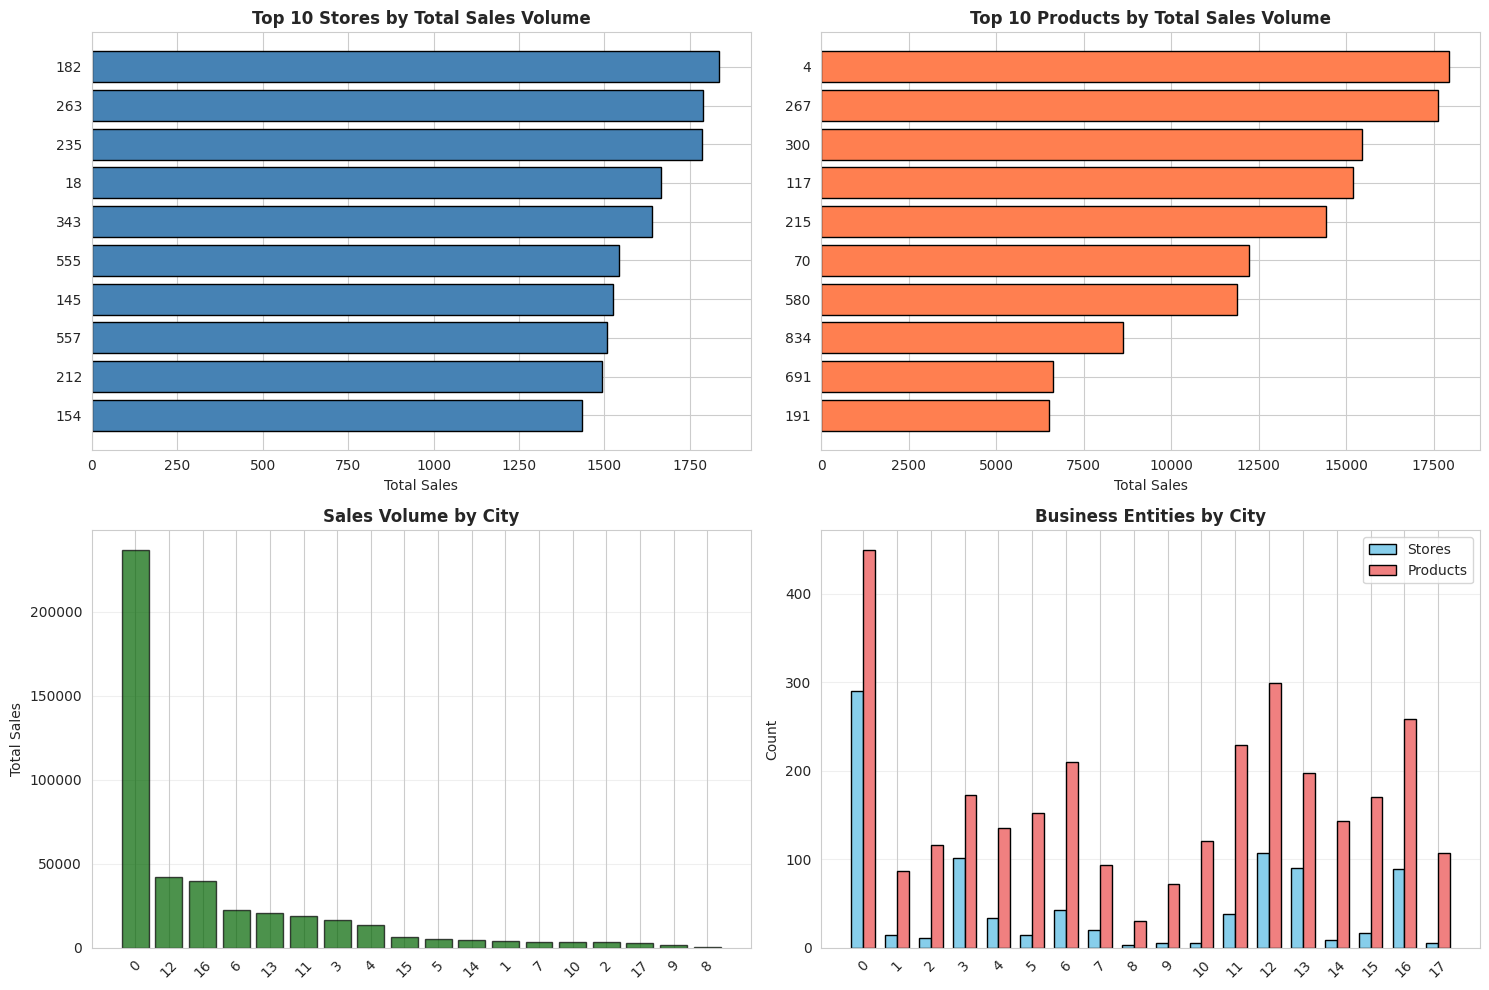

In [6]:
print("=" * 80)
print("BUSINESS DIMENSIONS ANALYSIS")
print("=" * 80)

print("\n🏪 Stores:")
print(f"  • Total unique stores: {train_data['store_id'].nunique()}")
print(f"  • Store statistics:")
store_stats = train_data.groupby('store_id')[target_col].agg(['count', 'mean', 'std', 'min', 'max']).describe()
print(store_stats)

print("\n📦 Products:")
print(f"  • Total unique products: {train_data['product_id'].nunique()}")
print(f"  • Product statistics:")
product_stats = train_data.groupby('product_id')[target_col].agg(['count', 'mean', 'std', 'min', 'max']).describe()
print(product_stats)

print("\n🏙️ Cities:")
print(f"  • Total unique cities: {train_data['city_id'].nunique()}")
print(f"  • City statistics:")
city_stats = train_data.groupby('city_id')[target_col].agg(['count', 'mean', 'std', 'min', 'max']).describe()
print(city_stats)

# Visualize top stores, products, cities
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Top 10 stores by sales volume
top_stores = train_data.groupby('store_id')[target_col].sum().nlargest(10)
axes[0, 0].barh(range(len(top_stores)), top_stores.values, color='steelblue', edgecolor='black')
axes[0, 0].set_yticks(range(len(top_stores)))
axes[0, 0].set_yticklabels(top_stores.index)
axes[0, 0].set_title('Top 10 Stores by Total Sales Volume', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Total Sales')
axes[0, 0].invert_yaxis()

# Top 10 products by sales volume
top_products = train_data.groupby('product_id')[target_col].sum().nlargest(10)
axes[0, 1].barh(range(len(top_products)), top_products.values, color='coral', edgecolor='black')
axes[0, 1].set_yticks(range(len(top_products)))
axes[0, 1].set_yticklabels(top_products.index)
axes[0, 1].set_title('Top 10 Products by Total Sales Volume', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Total Sales')
axes[0, 1].invert_yaxis()

# Cities by sales volume
city_sales = train_data.groupby('city_id')[target_col].sum().sort_values(ascending=False)
axes[1, 0].bar(range(len(city_sales)), city_sales.values, color='darkgreen', alpha=0.7, edgecolor='black')
axes[1, 0].set_xticks(range(len(city_sales)))
axes[1, 0].set_xticklabels(city_sales.index, rotation=45)
axes[1, 0].set_title('Sales Volume by City', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Total Sales')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Store count by city
store_by_city = train_data.groupby('city_id')['store_id'].nunique()
product_by_city = train_data.groupby('city_id')['product_id'].nunique()
x = range(len(store_by_city))
width = 0.35
axes[1, 1].bar([i - width/2 for i in x], store_by_city.values, width, label='Stores', color='skyblue', edgecolor='black')
axes[1, 1].bar([i + width/2 for i in x], product_by_city.values, width, label='Products', color='lightcoral', edgecolor='black')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(store_by_city.index, rotation=45)
axes[1, 1].set_title('Business Entities by City', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. Numerical Features Analysis

NUMERICAL FEATURES ANALYSIS

🔢 Numerical Features: 20 features
  Features: ['city_id', 'store_id', 'management_group_id', 'first_category_id', 'second_category_id', 'third_category_id', 'product_id', 'sale_amount', 'stock_hour6_22_cnt', 'discount', 'holiday_flag', 'activity_flag', 'precpt', 'avg_temperature', 'avg_humidity', 'avg_wind_level', 'hour', 'day_of_week', 'month', 'day_of_month']

📊 Correlation with Target Variable (sale_amount):
sale_amount            1.000000
holiday_flag           0.081127
second_category_id     0.062957
day_of_week            0.060949
month                  0.060352
avg_temperature        0.057288
management_group_id    0.045969
avg_humidity           0.043720
precpt                 0.037593
first_category_id      0.030398
day_of_month           0.013238
activity_flag          0.010367
store_id              -0.007172
avg_wind_level        -0.008753
city_id               -0.008999
Name: sale_amount, dtype: float64

📊 Correlation with Target Variable (sale_

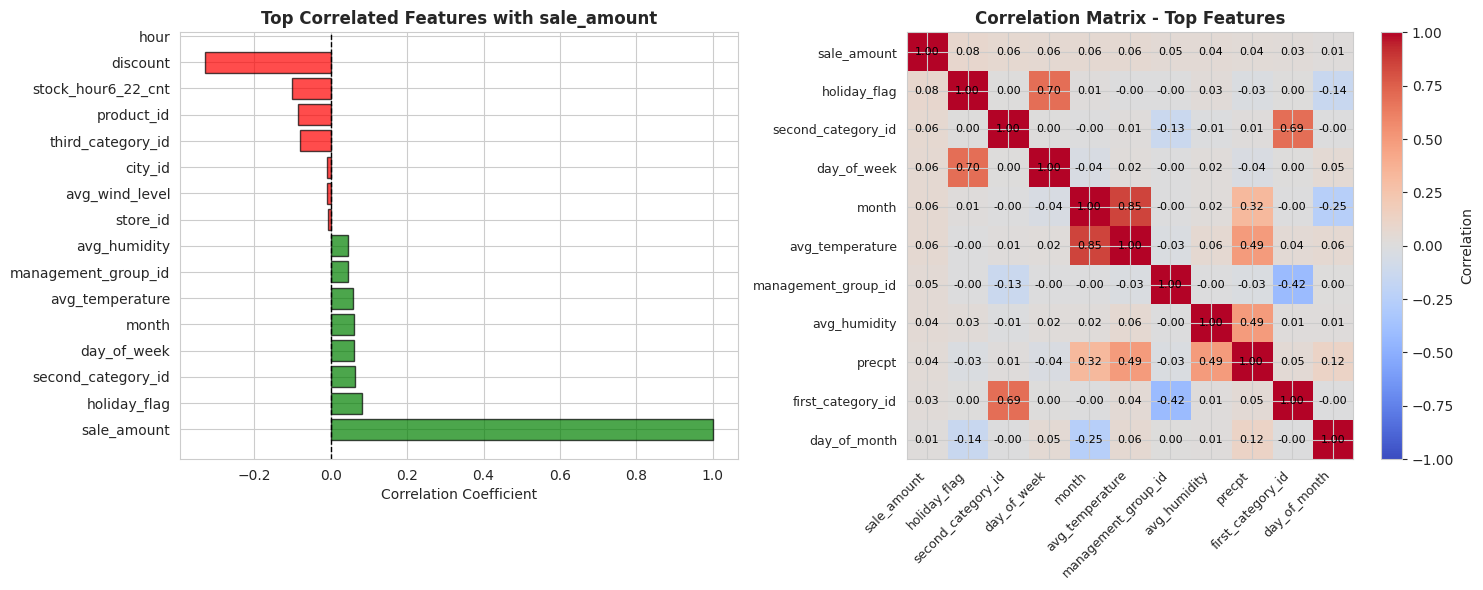


📈 Summary Statistics of Numerical Features:
                        count        mean         std    min       25%  \
city_id              450000.0    4.976667    6.094184   0.00    0.0000   
store_id             450000.0  409.909322  248.834866   0.00  195.0000   
management_group_id  450000.0    4.623782    1.960029   0.00    4.0000   
first_category_id    450000.0   15.215922    8.969400   0.00    5.0000   
second_category_id   450000.0   44.777642   22.343602   0.00   28.0000   
third_category_id    450000.0  116.263631   57.486704   0.00   77.0000   
product_id           450000.0  389.931796  263.286246   0.00  135.0000   
sale_amount          450000.0    0.994182    1.384504   0.00    0.4000   
stock_hour6_22_cnt   450000.0    3.192433    4.601373   0.00    0.0000   
discount             450000.0    0.911378    0.127860   0.00    0.8510   
holiday_flag         450000.0    0.344627    0.475247   0.00    0.0000   
activity_flag        450000.0    0.378416    0.484993   0.00    0.0

In [7]:
print("=" * 80)
print("NUMERICAL FEATURES ANALYSIS")
print("=" * 80)

# Get numerical columns
numerical_cols = train_data.select_dtypes(include=[np.number]).columns.tolist()

print(f"\n🔢 Numerical Features: {len(numerical_cols)} features")
print(f"  Features: {numerical_cols}")

# Correlation with target
correlations = train_data[numerical_cols].corr()[target_col].sort_values(ascending=False)
print(f"\n📊 Correlation with Target Variable ({target_col}):")
print(correlations.head(15))

# Visualize correlations
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top positive and negative correlations
top_corr = pd.concat([correlations.head(8), correlations.tail(8)])
colors = ['green' if x > 0 else 'red' for x in top_corr.values]
axes[0].barh(range(len(top_corr)), top_corr.values, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_yticks(range(len(top_corr)))
axes[0].set_yticklabels(top_corr.index)
axes[0].set_title(f'Top Correlated Features with {target_col}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Correlation Coefficient')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1)

# Correlation matrix heatmap (top 10 features)
top_features = correlations.abs().head(11).index.tolist()  # Including target
corr_matrix = train_data[top_features].corr()
im = axes[1].imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
axes[1].set_xticks(range(len(top_features)))
axes[1].set_yticks(range(len(top_features)))
axes[1].set_xticklabels(top_features, rotation=45, ha='right', fontsize=9)
axes[1].set_yticklabels(top_features, fontsize=9)
axes[1].set_title('Correlation Matrix - Top Features', fontsize=12, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=axes[1])
cbar.set_label('Correlation')

# Add correlation values to heatmap
for i in range(len(top_features)):
    for j in range(len(top_features)):
        text = axes[1].text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                           ha="center", va="center", color="black", fontsize=8)

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\n📈 Summary Statistics of Numerical Features:")
print(train_data[numerical_cols].describe().T)

## 8. Key Insights and Recommendations

### Summary of Findings

Based on the comprehensive exploratory data analysis, we have identified:

1. **Data Characteristics:**
   - Large-scale dataset with hundreds of thousands of transactions
   - Multiple business dimensions (stores, products, cities)
   - Rich temporal structure with clear patterns

2. **Target Variable (Sales):**
   - Non-normal distribution with potential right skew
   - Significant temporal seasonality at hourly, daily, and monthly levels
   - Clear business cycles and trends

3. **Key Patterns:**
   - **Hourly seasonality**: Strong variations across hours of the day
   - **Day-of-week effects**: Clear patterns in customer behavior by day
   - **Monthly trends**: Seasonal peaks and valleys throughout the year
   - **Store/Product heterogeneity**: Significant variation across stores and products

4. **Recommendations for Modeling:**
   - Use temporal features (hour, day, month) as strong predictors
   - Consider store and product aggregations for personalization
   - Implement ensemble methods to capture complex patterns
   - Handle potential outliers and skewed distributions
   - Use cross-validation to account for temporal dependencies